In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Load the dataset
df = pd.read_csv(r'D:\semester 10\[NETW1013] Machine Learning\Lab 4\GUC_2350_68_66115_2026-03-11T14_43_16\Lab 4\data_banknote_authentication.csv')

# Quick look at the data
print(df.head())
print(df.info())

# Split into features (X) and target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

   Variance_Wavelet  Skewness_Wavelet  Curtosis_Wavelet  Image_Entropy  Class
0           3.62160            8.6661           -2.8073       -0.44699      0
1           4.54590            8.1674           -2.4586       -1.46210      0
2           3.86600           -2.6383            1.9242        0.10645      0
3           3.45660            9.5228           -4.0112       -3.59440      0
4           0.32924           -4.4552            4.5718       -0.98880      0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Variance_Wavelet  1372 non-null   float64
 1   Skewness_Wavelet  1372 non-null   float64
 2   Curtosis_Wavelet  1372 non-null   float64
 3   Image_Entropy     1372 non-null   float64
 4   Class             1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB
None


In [3]:
# --- Decision Tree with GridSearchCV ---

# Define the parameter grid we want to search over
dt_param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10]
}

# Initialize the Decision Tree classifier
dt_model = DecisionTreeClassifier(random_state=42)

# Setup GridSearchCV
dt_grid_search = GridSearchCV(estimator=dt_model, param_grid=dt_param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit the model to the training data
dt_grid_search.fit(X_train, y_train)

# Extract the best model
best_dt_model = dt_grid_search.best_estimator_

print("Best Parameters for Decision Tree:", dt_grid_search.best_params_)
print("Best Cross-Validation Accuracy (Decision Tree): {:.4f}".format(dt_grid_search.best_score_))

Best Parameters for Decision Tree: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2}
Best Cross-Validation Accuracy (Decision Tree): 0.9836


--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       148
           1       1.00      0.96      0.98       127

    accuracy                           0.98       275
   macro avg       0.98      0.98      0.98       275
weighted avg       0.98      0.98      0.98       275



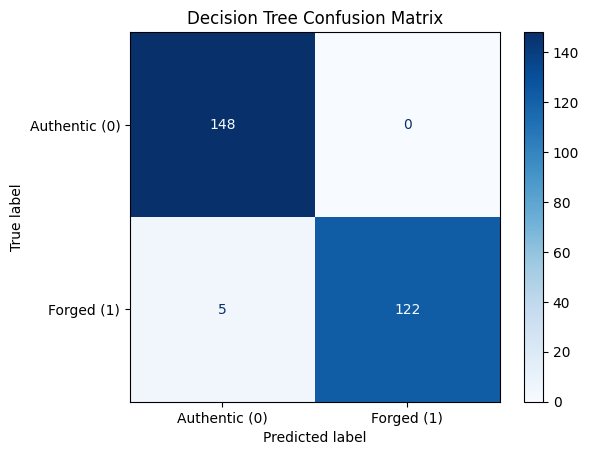

In [4]:
# ==========================================
# EVALUATE DECISION TREE
# ==========================================
# Predict on the test set using the best Decision Tree model
y_pred_dt = best_dt_model.predict(X_test)

# Print Classification Report
print("--- Decision Tree Classification Report ---")
print(classification_report(y_test, y_pred_dt))

# Plot Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Authentic (0)', 'Forged (1)'])
disp_dt.plot(cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.show()

In [5]:
# ==========================================
# RANDOM FOREST WITH GRIDSEARCHCV
# ==========================================
# Define the parameter grid we want to search over for Random Forest
rf_param_grid = {
    'n_estimators': [50, 100, 150],       # Number of trees
    'max_depth': [None, 10, 20],          # Maximum depth of the trees
    'min_samples_split': [2, 5]           # Minimum number of samples required to split
}

# Initialize the Random Forest classifier
rf_model = RandomForestClassifier(random_state=42)

# Setup GridSearchCV
rf_grid_search = GridSearchCV(estimator=rf_model, param_grid=rf_param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit the model to the training data
rf_grid_search.fit(X_train, y_train)

# Extract the best model
best_rf_model = rf_grid_search.best_estimator_

print("\n--- Random Forest GridSearchCV Results ---")
print("Best Parameters for Random Forest:", rf_grid_search.best_params_)
print("Best Cross-Validation Accuracy (Random Forest): {:.4f}".format(rf_grid_search.best_score_))


--- Random Forest GridSearchCV Results ---
Best Parameters for Random Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best Cross-Validation Accuracy (Random Forest): 0.9918


--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       148
           1       0.99      0.98      0.99       127

    accuracy                           0.99       275
   macro avg       0.99      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275



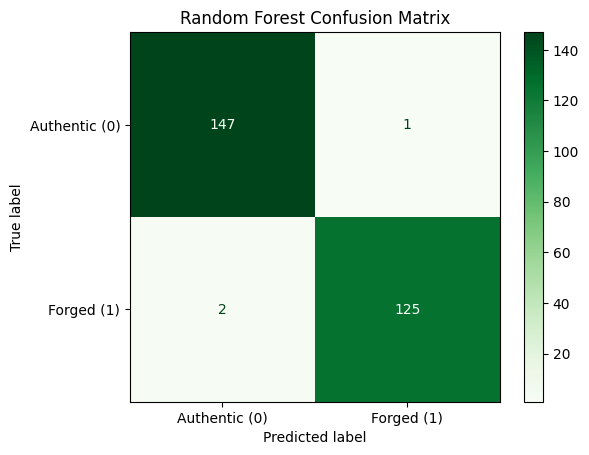

In [7]:
# ==========================================
# EVALUATE RANDOM FOREST
# ==========================================
# Predict on the test set using the best Random Forest model
y_pred_rf = best_rf_model.predict(X_test)

# Print Classification Report
print("--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf))

# Plot Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Authentic (0)', 'Forged (1)'])
disp_rf.plot(cmap='Greens')
plt.title('Random Forest Confusion Matrix')
plt.show()

In [ ]:

# Overall Performance: Both models performed exceptionally well in classifying the banknotes
# The Decision Tree achieved an impressive accuracy of 98%, while the Random Forest performed even better with an accuracy of 99%

# Precision and Recall: The Decision Tree had perfect precision (1.00) for forged notes (Class 1) but a slightly lower recall (0.96)
# meaning it missed a few forged notes
# The Random Forest provided a more balanced performance across both classes with precision recall and f1-scores consistently at 0.98 or 0.99

# The Decision Tree, being a single tree, is slightly more prone to overfitting the training data
# The Random Forest which is an ensemble of multiple decision trees (50 in our tuned model)
# averages out the predictions
# This reduces variance, improves generalization to unseen data, and yields more robust and balanced predictions